# Momentum Factors: Mom_6_1 vs Mom_12_1

**Mục tiêu:**
1. Tính momentum factor (bỏ tháng gần nhất, tránh short-term reversal) trên universe 28 mã đã làm sạch
2. So sánh Mom_6_1 và Mom_12_1 — khác biệt về cách tính, đo IC/IC-IR bằng `src/ic_analysis.py`
3. Quintile analysis — kiểm tra pattern "winner tiếp tục thắng, loser tiếp tục thua" trên VN30

⚠️ Notebook này dùng module đã tách trong `src/` (`momentum_factors.py`, `ic_analysis.py`,
`data_loader.py`) — không định nghĩa lại hàm ở đây, chỉ import và gọi.


In [1]:
# -*- coding: utf-8 -*-
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import VN30_UNIVERSE, load_ohlcv, filter_by_coverage
from src.momentum_factors import (
    momentum_6_1, momentum_12_1, compare_momentum_variants,
    forward_return, quintile_forward_returns, is_monotonic_winner_pattern,
)
from src.ic_analysis import single_factor_ic, full_oos_ic_ir

pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 1. Tải dữ liệu + lọc universe (giống Ngày 19)

In [2]:
START, END = "2022-01-01", "2025-12-31"  # đủ 252 phiên cho Mom_12_1

ohlcv = load_ohlcv(VN30_UNIVERSE, START, END, fields=("close", "open", "volume"))
price_df = ohlcv["close"]

price_df, dropped = filter_by_coverage(price_df)
print(f"Universe đã làm sạch: {len(price_df.columns)}/{len(VN30_UNIVERSE)} mã")
print(f"Loại: {dropped}")


[1/30] Loading ACB...


[2/30] Loading BID...
[3/30] Loading BSR...
[4/30] Loading CTG...
[5/30] Loading FPT...
[6/30] Loading GAS...
[7/30] Loading GVR...
[8/30] Loading HDB...
[9/30] Loading HPG...
[10/30] Loading LPB...
[11/30] Loading MBB...
[12/30] Loading MCH...


[13/30] Loading MSN...
[14/30] Loading MWG...
[15/30] Loading SAB...
[16/30] Loading SHB...
[17/30] Loading SSB...
[18/30] Loading SSI...
⏳ Nghỉ 65s để tránh rate limit...
[19/30] Loading STB...
[20/30] Loading TCB...
[21/30] Loading TCX...
[22/30] Loading VCB...
[23/30] Loading VHM...
[24/30] Loading VIB...
[25/30] Loading VIC...
[26/30] Loading VJC...
[27/30] Loading VNM...
[28/30] Loading VPB...
[29/30] Loading VPL...
[30/30] Loading VRE...



✅ Đã tải: 30/30 mã
Universe đã làm sạch: 28/30 mã
Loại: ['TCX', 'VPL']


## 2. Tính Momentum Factor (bỏ tháng gần nhất)

- **Mom_6_1** = giá(t-21) / giá(t-126) − 1 (lookback 6 tháng, bỏ 1 tháng gần nhất)
- **Mom_12_1** = giá(t-21) / giá(t-252) − 1 (lookback 12 tháng, bỏ 1 tháng gần nhất)

Cả 2 công thức bỏ 21 phiên gần nhất (~1 tháng) để tránh **short-term reversal**
— hiện tượng giá thường đảo chiều ngắn hạn ngay sau khi tăng/giảm mạnh, làm
nhiễu tín hiệu momentum trung-dài hạn nếu tính luôn tháng gần nhất.

In [3]:
mom_6_1 = momentum_6_1(price_df)
mom_12_1 = momentum_12_1(price_df)

print("Mom_6_1 shape:", mom_6_1.shape, "| non-NaN cuối:", mom_6_1.iloc[-1].notna().sum())
print("Mom_12_1 shape:", mom_12_1.shape, "| non-NaN cuối:", mom_12_1.iloc[-1].notna().sum())


Mom_6_1 shape: (997, 28) | non-NaN cuối: 28
Mom_12_1 shape: (997, 28) | non-NaN cuối: 28


## 3. So sánh 2 biến thể — khác biệt về cách tính?

Cả 2 dùng CHUNG công thức tổng quát `giá(t-21) / giá(t-N) - 1`, chỉ khác N
(126 vs 252 phiên). Khác biệt về bản chất:
- **Mom_6_1**: nhạy hơn với biến động gần đây, phản ứng nhanh khi regime đổi chiều, nhưng nhiễu hơn.
- **Mom_12_1**: ổn định hơn (nhiều observation hơn để "làm mượt"), nhưng phản ứng chậm hơn.

In [4]:
cmp_df = compare_momentum_variants(price_df)
print(cmp_df)


                              value
metric                             
Pearson corr (mean)          0.7219
Spearman corr (mean)         0.6820
% ngày đồng thuận dấu (mean) 0.7504


### 3.1 Đo IC / IC-IR bằng `ic_analysis.py` (Purged K-Fold OOS)

In [5]:
from src.feature_engineering import assemble_dataset

raw_factors = {"Momentum_6_1": mom_6_1, "Momentum_12_1": mom_12_1}
dataset = assemble_dataset(raw_factors, price_df, n_fwd=5, label_type="regression")
print(f"Dataset: {dataset.shape}, khoảng {dataset.index.get_level_values('date').min().date()} "
      f"→ {dataset.index.get_level_values('date').max().date()}")

feature_cols = list(raw_factors.keys())
sf_ic = single_factor_ic(dataset, feature_cols, n_splits=5, embargo=5)
print("\n=== Mean IC (Purged K-Fold OOS) ===")
print(sf_ic)


Dataset: (20681, 3), khoảng 2023-01-06 → 2025-12-24

=== Mean IC (Purged K-Fold OOS) ===
Momentum_6_1    0.0524
Momentum_12_1   0.0435
Name: Mean IC, dtype: float64


In [6]:
# IC-IR đầy đủ (dùng toàn bộ daily IC gộp, không chỉ mean-of-mean)
for feat in feature_cols:
    stats = full_oos_ic_ir(dataset, feat, n_splits=5, embargo=5)
    print(f"\n{feat}:")
    for k, v in stats.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")



Momentum_6_1:
  Mean IC: 0.0524
  Std IC: 0.2745
  IC-IR: 0.1910
  IC>0 (%): 0.5743
  N Obs: 740

Momentum_12_1:
  Mean IC: 0.0435
  Std IC: 0.2939
  IC-IR: 0.1480
  IC>0 (%): 0.5446
  N Obs: 740


## 4. Quintile Analysis — pattern "winner tiếp tục thắng"?

Chia universe thành 5 quintile theo momentum score mỗi ngày (cross-sectional),
tính forward return trung bình mỗi quintile. Nếu pattern momentum classical
đúng: return phải tăng ĐƠN ĐIỆU từ Q1 (loser) → Q5 (winner).

⚠️ Thị trường VN nhỏ, thanh khoản thấp — kết quả CÓ THỂ khác Mỹ (nơi
momentum là anomaly kinh điển, well-documented từ Jegadeesh-Titman 1993).

In [7]:
fwd_ret = forward_return(price_df, n_fwd=5)

print("=== Quintile analysis: Mom_6_1 ===")
qret_6_1 = quintile_forward_returns(mom_6_1, fwd_ret, n_quintiles=5)
print(qret_6_1)
print(is_monotonic_winner_pattern(qret_6_1))


=== Quintile analysis: Mom_6_1 ===
          mean_fwd_return  std_fwd_return  n_obs
quintile                                        
1                  0.0020          0.0497   5186
2                  0.0032          0.0451   4330
3                  0.0043          0.0420   5177
4                  0.0047          0.0437   4330
5                  0.0067          0.0482   5186
{'monotonic_Q1_to_Q5': True, 'Q5_minus_Q1_spread': 0.0047144885379789125, 'spread_direction': 'winner-thắng-tiếp (như kỳ vọng)'}


In [8]:
print("=== Quintile analysis: Mom_12_1 ===")
qret_12_1 = quintile_forward_returns(mom_12_1, fwd_ret, n_quintiles=5)
print(qret_12_1)
print(is_monotonic_winner_pattern(qret_12_1))


=== Quintile analysis: Mom_12_1 ===
          mean_fwd_return  std_fwd_return  n_obs
quintile                                        
1                  0.0050          0.0454   4440
2                  0.0018          0.0347   3700
3                  0.0051          0.0408   4425
4                  0.0051          0.0421   3684
5                  0.0077          0.0468   4440
{'monotonic_Q1_to_Q5': False, 'Q5_minus_Q1_spread': 0.002684348476022616, 'spread_direction': 'winner-thắng-tiếp (như kỳ vọng)'}


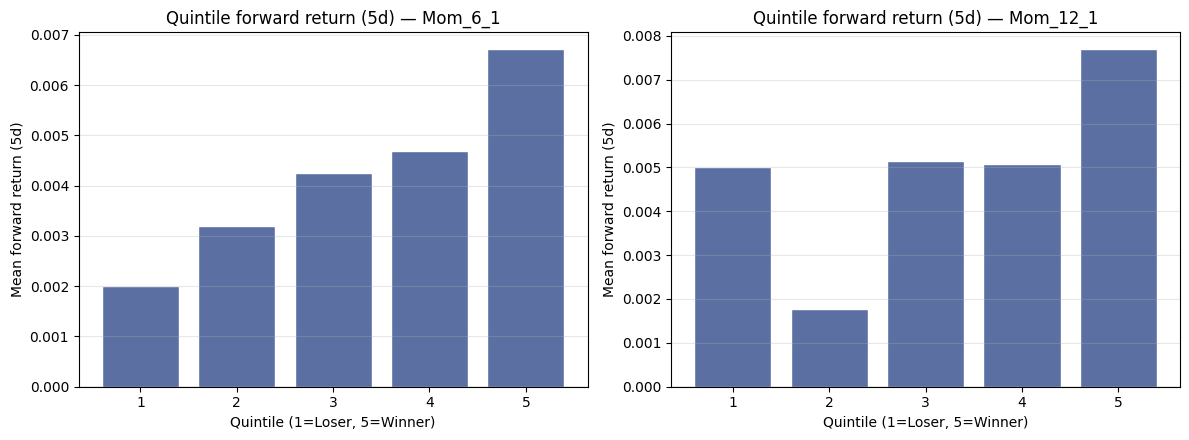

✅ Đã lưu: reports/day18_quintile_returns.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, qret, name in [(axes[0], qret_6_1, "Mom_6_1"), (axes[1], qret_12_1, "Mom_12_1")]:
    ax.bar(qret.index.astype(str), qret["mean_fwd_return"], color="#5b6fa2", edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Quintile forward return (5d) — {name}")
    ax.set_xlabel("Quintile (1=Loser, 5=Winner)")
    ax.set_ylabel("Mean forward return (5d)")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../reports/day18_quintile_returns.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Đã lưu: reports/day18_quintile_returns.png")


## 5. Kết luận Ngày 18

- Ghi lại IC, pattern quintile (đơn điệu hay không) sau khi chạy với dữ liệu THẬT.
- Nếu pattern KHÔNG đơn điệu hoặc spread Q5-Q1 yếu/âm — đây là quan sát quan
  trọng để đưa vào `reports/research_note.md`, KHÔNG che giấu hay "làm đẹp" kết quả.
- Xem `reports/research_note.md` để biết diễn giải đầy đủ theo chuẩn
  Observation/Hypothesis/Evidence/Conclusion.